# Seasonal Agriculture Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/ashra/Downloads/seasonal_agriculture_performance_dataset.csv")

In [3]:
df.head(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3
5,SF10006,Gujarat,Raichur,Pulses,Zaid,5.46,356.0,33.6,49.0,8.3,...,0.89,0.72,3.93,68593,302333,269570,-32763,1093,3.596,57.1
6,SF10007,Telangana,Warangal,Wheat,Rabi,8.13,432.2,23.5,50.8,9.5,...,0.87,2.53,20.57,22951,513341,472102,-41239,2368,8.687,31.6
7,SF10008,Tamil Nadu,Ludhiana,Pulses,Kharif,5.34,860.2,29.0,64.9,7.9,...,0.70,1.18,6.30,70042,436200,441265,5065,1704,3.697,54.2
8,SF10009,Karnataka,Guntur,Cotton,Zaid,6.98,624.7,33.4,46.8,7.9,...,0.88,1.53,10.68,70771,525129,755834,230705,5079,2.103,54.7
9,SF10010,Tamil Nadu,Raichur,Chilli,Rabi,13.69,415.8,22.3,57.3,8.6,...,0.70,2.29,31.35,94383,1004072,2958907,1954835,5984,5.239,41.7


In [4]:
df.tail(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3990,SF13991,Tamil Nadu,Indore,Cotton,Kharif,6.58,1072.3,28.0,79.6,7.3,...,0.70,1.62,10.66,72931,388777,777444,388667,6259,1.703,41.1
3991,SF13992,Telangana,Rajkot,Chilli,Zaid,2.04,338.8,34.4,69.0,7.5,...,0.82,1.07,2.18,80847,137231,176246,39015,854,2.553,41.8
3992,SF13993,Karnataka,Rajkot,Groundnut,Rabi,2.03,579.9,20.4,56.5,8.0,...,0.66,1.61,3.27,58117,139340,190043,50703,1416,2.309,38.6
3993,SF13994,Gujarat,Rajkot,Cotton,Rabi,13.48,308.9,25.0,70.8,8.1,...,0.89,1.33,17.93,71268,1053465,1277835,224370,10589,1.693,43.7
3994,SF13995,Maharashtra,Ludhiana,Wheat,Kharif,9.20,1243.8,27.5,66.5,7.4,...,0.70,2.18,20.06,23314,618838,467679,-151159,5577,3.597,67.1
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


## Meta Data

In [5]:
print("No.of Rows:",df.shape[0])
print("No.of Columns:",df.shape[1])

No.of Rows: 4000
No.of Columns: 28


In [6]:
df.info

<bound method DataFrame.info of       Farm_ID           State  District    Crop  Season  Farm_Area_Hectares  \
0     SF10001  Andhra Pradesh    Rajkot   Wheat  Kharif                0.53   
1     SF10002     Maharashtra  Nalgonda   Maize  Kharif                6.53   
2     SF10003       Telangana  Warangal  Pulses    Rabi                4.86   
3     SF10004       Telangana    Indore    Rice  Kharif                4.50   
4     SF10005       Karnataka  Ludhiana   Maize    Zaid                4.21   
...       ...             ...       ...     ...     ...                 ...   
3995  SF13996       Karnataka    Rajkot   Wheat  Kharif                4.72   
3996  SF13997       Karnataka   Krishna  Chilli  Kharif                8.77   
3997  SF13998  Andhra Pradesh     Erode  Pulses    Zaid               10.47   
3998  SF13999          Punjab  Warangal  Cotton  Kharif                1.73   
3999  SF14000          Punjab    Nashik   Wheat  Kharif                3.31   

      Rainfall_mm  

## Data Types

In [7]:
print("The Data Types are:",df.dtypes)

The Data Types are: Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        in

## Data Description

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


### Duplicate Values in the Data

In [9]:
duplicate_count=df.duplicated().sum()
print("Duplicate Values:",duplicate_count)

Duplicate Values: 0


### Missing Values

In [10]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

print(missing)

                               Missing Count  Missing %
Farm_ID                                    0        0.0
State                                      0        0.0
District                                   0        0.0
Crop                                       0        0.0
Season                                     0        0.0
Farm_Area_Hectares                         0        0.0
Rainfall_mm                               48        1.2
Avg_Temperature_C                          0        0.0
Humidity_pct                               0        0.0
Sunlight_Hours_Day                         0        0.0
Soil_pH                                    0        0.0
Soil_Moisture_pct                         40        1.0
Nitrogen_kg_ha                             0        0.0
Phosphorus_kg_ha                           0        0.0
Potassium_kg_ha                            0        0.0
Irrigation_Method                          0        0.0
Fertilizer_kg_ha                           0    

In [11]:

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

C:\Users\ashra\AppData\Local\Temp\ipykernel_13080\3279495557.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [12]:
print('Missing values in categorical columns after filling:')
print(df[categorical_columns].isna().sum())

Missing values in categorical columns after filling:
Farm_ID              0
State                0
District             0
Crop                 0
Season               0
Irrigation_Method    0
dtype: int64


## KPI's

### Net Profit & Loss

In [13]:
net_profit_loss = df['Profit_INR'].sum()
print(f"Net Profit/Loss: {net_profit_loss:.2f} INR")

Net Profit/Loss: 446225860.00 INR


### Cost per Hectare & Revenue per Hectare

In [14]:
df['Cost_Per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_Per_Hectare'] = df['Revenue_INR'] / df['Farm_Area_Hectares']
display(df.head())

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Cost_Per_Hectare,Revenue_Per_Hectare
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,1.30,23700,42662,30810,-11852,237,5.485,55.3,80494.339623,58132.075472
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,1.96,20613,492351,40401,-451950,4953,0.396,49.9,75398.315467,6186.983155
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,2.53,75283,315210,190466,-124744,1275,1.984,33.7,64858.024691,39190.534979
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,8.28,24244,296444,200740,-95704,3834,2.160,50.6,65876.444444,44608.888889
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,9.30,20818,337959,193607,-144352,3287,2.829,32.3,80275.296912,45987.410926


## Data Visualization

C:\Users\ashra\AppData\Local\Temp\ipykernel_13080\1158915051.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=yield_by_season, palette='viridis')


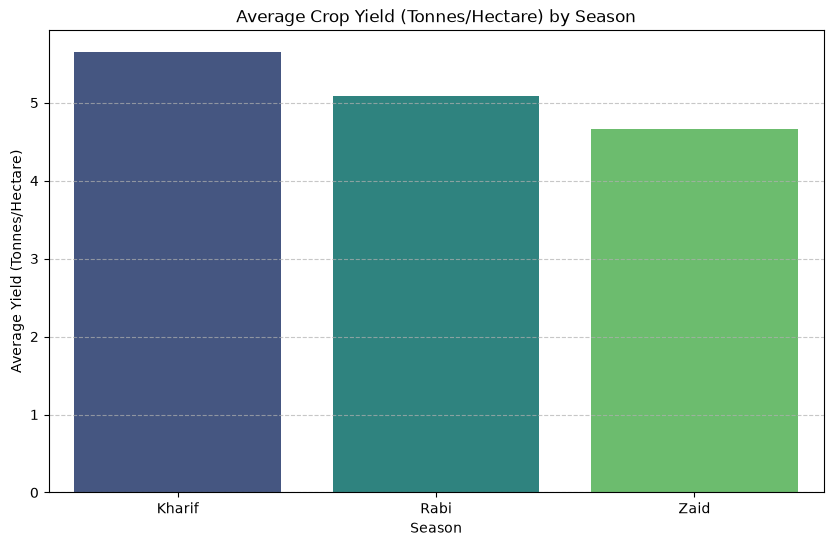

In [15]:
yield_by_season = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=yield_by_season, palette='viridis')
plt.title('Average Crop Yield (Tonnes/Hectare) by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


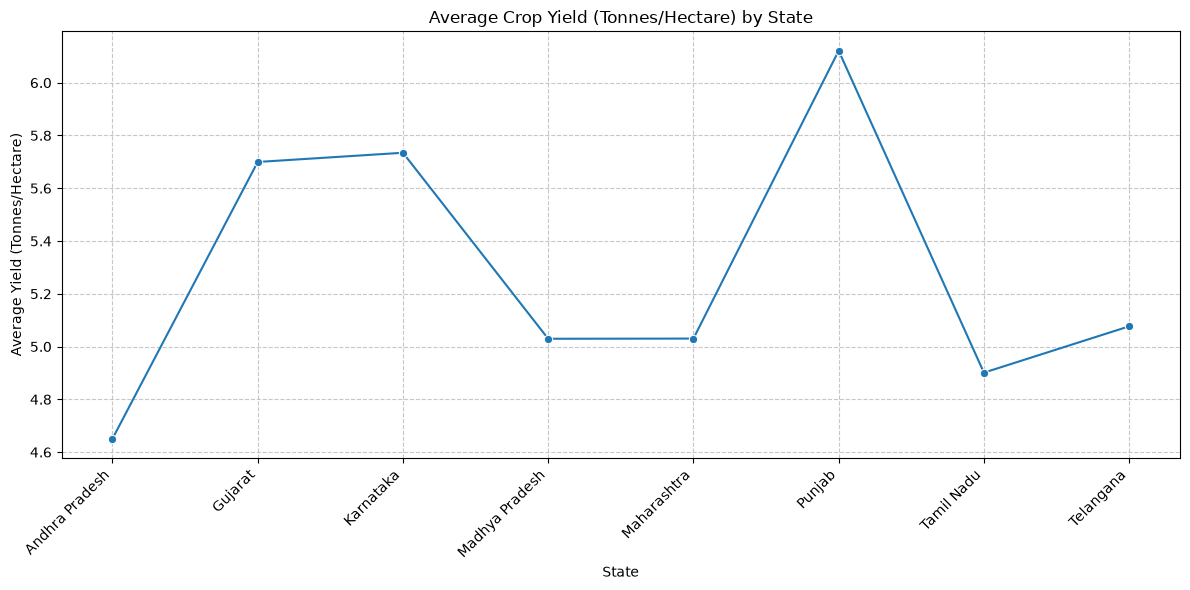

In [16]:
yield_by_state = df.groupby('State')['Yield_Tonnes_Ha'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='State', y='Yield_Tonnes_Ha', data=yield_by_state, marker='o')
plt.title('Average Crop Yield (Tonnes/Hectare) by State')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Hectare)')
plt.xticks(rotation=45, ha='right') # Rotate state names for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

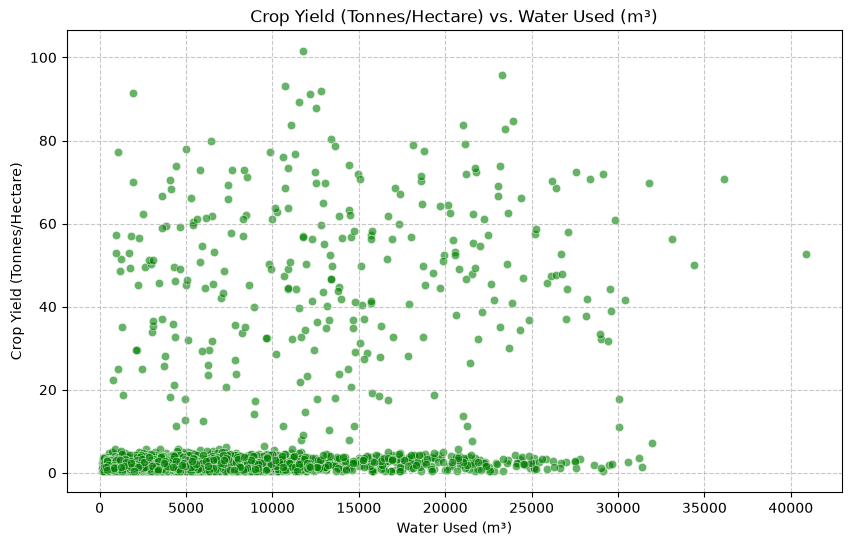

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Water_Used_m3', y='Yield_Tonnes_Ha', data=df, alpha=0.6, color='green')
plt.title('Crop Yield (Tonnes/Hectare) vs. Water Used (m³)')
plt.xlabel('Water Used (m³)')
plt.ylabel('Crop Yield (Tonnes/Hectare)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

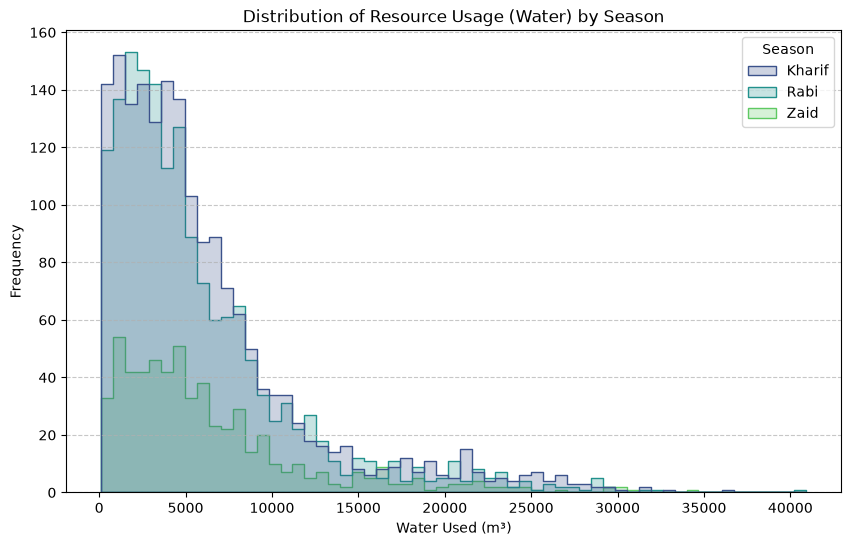

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Water_Used_m3', hue='Season', element='step', palette='viridis')
plt.title('Distribution of Resource Usage (Water) by Season')
plt.xlabel('Water Used (m³)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

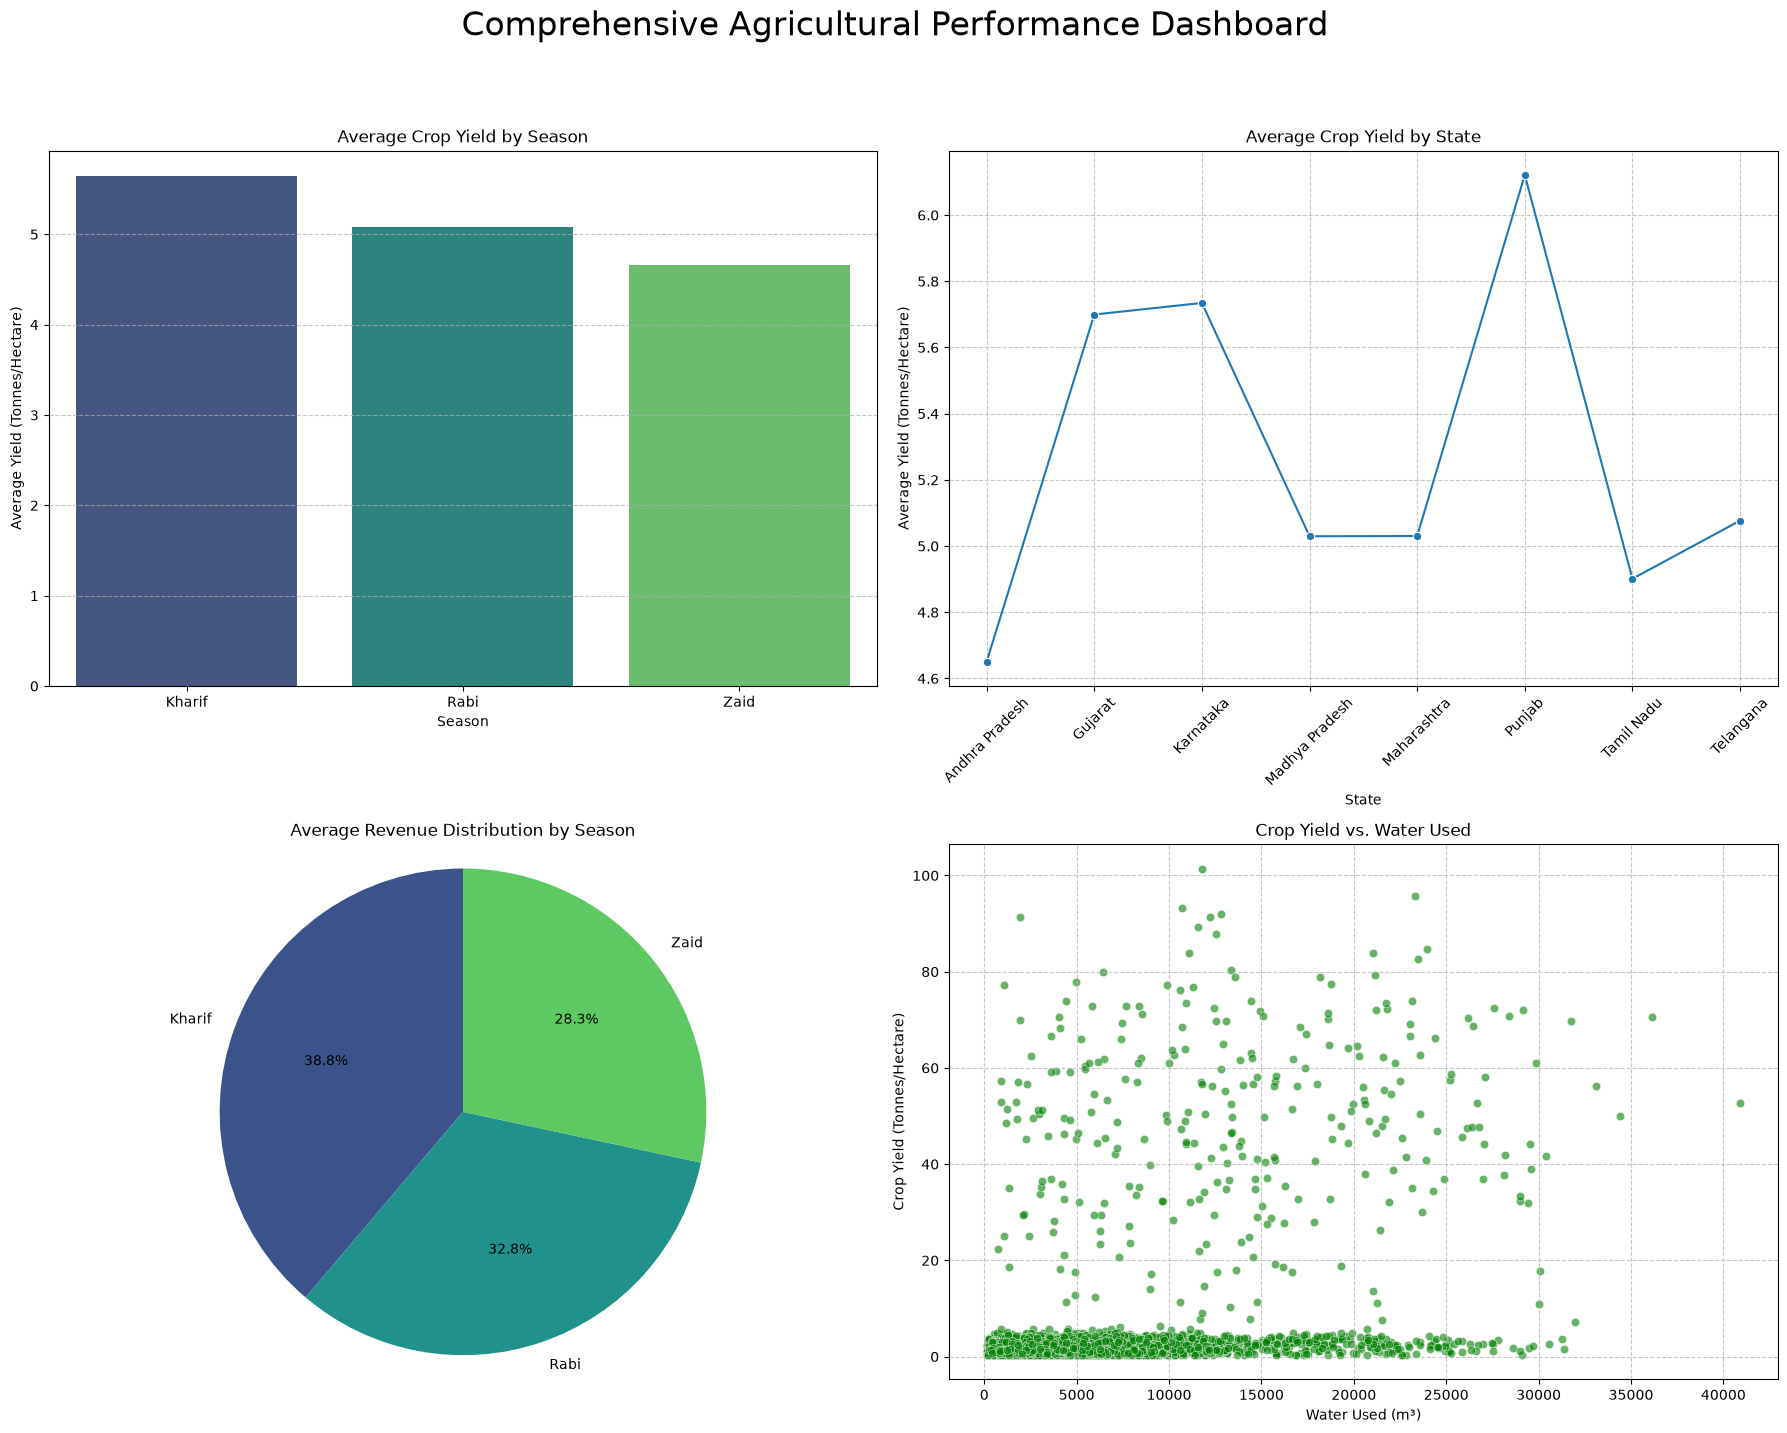

In [19]:

# Data aggregation steps (kept only what's needed for the remaining plots)
yield_by_season = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index()
yield_by_state = df.groupby('State')['Yield_Tonnes_Ha'].mean().reset_index()
revenue_by_season = df.groupby('Season')['Revenue_INR'].mean().reset_index() # Keep this as it's needed for the Pie chart

# Adjust subplot layout for 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 14))
fig.suptitle('Comprehensive Agricultural Performance Dashboard', fontsize=24, y=1.02)

# Plot 1: Average Crop Yield (Tonnes/Hectare) by Season
sns.barplot(x='Season', y='Yield_Tonnes_Ha', data=yield_by_season, palette='viridis', ax=axes[0, 0], hue='Season', legend=False)
axes[0, 0].set_title('Average Crop Yield by Season')
axes[0, 0].set_xlabel('Season')
axes[0, 0].set_ylabel('Average Yield (Tonnes/Hectare)')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Average Crop Yield (Tonnes/Hectare) by State
sns.lineplot(x='State', y='Yield_Tonnes_Ha', data=yield_by_state, marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Average Crop Yield by State')
axes[0, 1].set_xlabel('State')
axes[0, 1].set_ylabel('Average Yield (Tonnes/Hectare)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 3 (originally Plot 4): Average Revenue (INR) Distribution by Season (Pie Chart)
axes[1, 0].pie(
    x=revenue_by_season['Revenue_INR'],
    labels=revenue_by_season['Season'],
    autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '',
    startangle=90,
    colors=sns.color_palette('viridis', n_colors=len(revenue_by_season))
)
axes[1, 0].set_title('Average Revenue Distribution by Season')
axes[1, 0].axis('equal')

# Plot 4 (originally Plot 6): Crop Yield (Tonnes/Hectare) vs. Water Used (m³)
sns.scatterplot(x='Water_Used_m3', y='Yield_Tonnes_Ha', data=df, alpha=0.6, color='green', ax=axes[1, 1])
axes[1, 1].set_title('Crop Yield vs. Water Used')
axes[1, 1].set_xlabel('Water Used (m³)')
axes[1, 1].set_ylabel('Crop Yield (Tonnes/Hectare)')
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()